In [25]:
import sys
print(sys.executable)

/Users/megganshvartsberg/CS4120/.venv/bin/python


In [26]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from keras.preprocessing.sequence import pad_sequences

In [27]:
# view the three datasets
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

TRANSCRIPTS_PATH = Path("..") / "data" / "transcripts_cleaned.csv"

In [28]:
transcript_df = pd.read_csv(TRANSCRIPTS_PATH)
print(transcript_df.shape)
transcript_df.head()

(157, 7)


,Record-ID,Class,Transcript_PFT,Transcript_CTD,Transcript_SFT,Label,Binary_Label
0,Process-rec-001,MCI,"people, partner, plate, platter, pants, porter...",NaN,"<pause_medium> giraffe, kangaroo, lion, tiger,...",1,1
1,Process-rec-002,MCI,"<pause_short> pipe, plane, people <pause_mediu...",<pause_medium> there’s a lad stood on the stoo...,"<pause_short> dogs, cats, birds <pause_short> ...",1,1
2,Process-rec-003,MCI,"um <pause_short> purple, pale, placid <pause_s...","<pause_medium> um, the picture is of a kitchen...","cow, bull, ewe, ram, chicken, goose, um <sigh>...",1,1
3,Process-rec-004,MCI,plank <pause_short> pool <pause_short> swimmin...,"a mother presumably, or a fe, an adult female ...",um <pause_short> impala <pause_short> er cheet...,1,1
4,Process-rec-005,MCI,"it’s er pillock, er post box, er pyracanthas, ...","‘50s style er scene of domestic um confusion, ...","dog, cat, giraffe, wallaby, kangaroo, tortoise...",1,1


In [29]:
TRANSCRIPT_COLS = ["Transcript_PFT", "Transcript_CTD", "Transcript_SFT"]

print("NaN counts per transcript type: ")
for col in TRANSCRIPT_COLS:
    n_nans = transcript_df[col].isna().sum()
    print(f"{col}: {n_nans} NaNs")

NaN counts per transcript type: 
Transcript_PFT: 0 NaNs
Transcript_CTD: 1 NaNs
Transcript_SFT: 5 NaNs


In [30]:
transcript_df.columns

Index(['Record-ID', 'Class', 'Transcript_PFT', 'Transcript_CTD',
       'Transcript_SFT', 'Label', 'Binary_Label'],
      dtype='object')

In [31]:
pft_df = transcript_df[["Transcript_PFT", "Label"]]
ctd_df = transcript_df[['Transcript_CTD', 'Label']]
sft_df = transcript_df[['Transcript_SFT', 'Label']]

In [32]:
print("Phonemic Fluency Test \n")
pft_df.head()

Phonemic Fluency Test 



,Transcript_PFT,Label
0,"people, partner, plate, platter, pants, porter...",1
1,"<pause_short> pipe, plane, people <pause_mediu...",1
2,"um <pause_short> purple, pale, placid <pause_s...",1
3,plank <pause_short> pool <pause_short> swimmin...,1
4,"it’s er pillock, er post box, er pyracanthas, ...",1


In [33]:
print("Category Test: Delayed Recall \n")
ctd_df.head()

Category Test: Delayed Recall 



,Transcript_CTD,Label
0,NaN,1
1,<pause_medium> there’s a lad stood on the stoo...,1
2,"<pause_medium> um, the picture is of a kitchen...",1
3,"a mother presumably, or a fe, an adult female ...",1
4,"‘50s style er scene of domestic um confusion, ...",1


In [34]:
print("Semantic Fluency Test \n")
sft_df.head()

Semantic Fluency Test 



,Transcript_SFT,Label
0,"<pause_medium> giraffe, kangaroo, lion, tiger,...",1
1,"<pause_short> dogs, cats, birds <pause_short> ...",1
2,"cow, bull, ewe, ram, chicken, goose, um <sigh>...",1
3,um <pause_short> impala <pause_short> er cheet...,1
4,"dog, cat, giraffe, wallaby, kangaroo, tortoise...",1


# Setting up Training with Hyperparameter Search + Evaluation

In [35]:
from typing import Tuple, Optional, List
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

from transcript_preprocessing import get_stratified_kfold_splits


def train_eval_log_reg_text_only_kfold(
    classification: str,
    df: pd.DataFrame,
    text_col: str,
    label_col: str,
    n_splits: int = 5,
    random_state: int = 42,
) -> Tuple[Pipeline, np.ndarray, float, float, dict]:
    """
    Returns (final_model, fold_scores, mean_f1, std_f1, best_params)
    """

    # get rid of rows that are missing either the text or the label
    df = df.dropna(subset=[text_col, label_col]).copy().reset_index(drop=True)
    X = df[[text_col]]
    y = df[label_col]

    # TF-IDF on the text column
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transformer, text_col),
        ],
        remainder="drop",
    )

    # base logistic regression model
    base_log_reg = LogisticRegression(
        solver="lbfgs", 
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )

    base_clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("logreg", base_log_reg),
    ])

    # perform stratified folds
    splits = list(
        get_stratified_kfold_splits(
            transcript_df=df,
            transcript_col=text_col,
            label_col=label_col,
            n_splits=n_splits,
            seed=random_state,
        )
    )

    # gridSearchCV
    cv_for_grid = [(train_idx, test_idx) for (_, train_idx, test_idx) in splits]

    # hyperparameters
    param_grid = {
        "logreg__C": [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000],
        "logreg__solver": ["lbfgs", "newton-cg"],  
        "preprocess__text__ngram_range": [(1, 1), (1, 2), (2, 2)],
        "preprocess__text__min_df": [1, 2, 3, 4, 5, 6, 7, 8 , 9, 10],
        "preprocess__text__max_df": [0.8, 0.9, 1.0],
        "preprocess__text__max_features": [50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 1000],
    }

    grid = GridSearchCV(
        estimator=base_clf,
        param_grid=param_grid,
        cv=cv_for_grid,         
        scoring="f1_macro",
        n_jobs=-1,
    ) 

    grid.fit(X, y)
    best_clf_template: Pipeline = grid.best_estimator_
    best_params: dict = grid.best_params_

    print("\nGlobal GridSearchCV: ")
    print("Best params:", best_params)
    print(f"Best CV f1_macro: {grid.best_score_:.4f}")

    # K-fold evaluation with the best hyperparameters
    fold_scores: List[float] = []

    # collectors for global confusion matrix
    all_y_true: List[int] = []
    all_y_pred: List[int] = []

    for fold_idx, train_idx, test_idx in splits:

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        # clone the best pipeline so each fold starts from scratch but with best_params
        clf_fold = clone(best_clf_template)
        clf_fold.fit(X_train, y_train)

        y_pred = clf_fold.predict(X_test)

        # accumulate predictions for global confusio matrix
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        f1 = f1_score(y_test, y_pred, average="macro")
        fold_scores.append(f1)

    fold_scores = np.array(fold_scores)
    mean_f1 = fold_scores.mean()
    std_f1 = fold_scores.std()

    print(f"\nOverall ({n_splits}-fold): ")
    print(f"Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

    all_y_true_arr = np.array(all_y_true)
    all_y_pred_arr = np.array(all_y_pred)
    cm_all = confusion_matrix(all_y_true_arr, all_y_pred_arr)
    print("\nConfusion matrix over all folds: ")
    print("rows = true labels, cols = predicted labels")
    print(cm_all)
    print("Total samples in CM:", cm_all.sum())
    
    
    print("\nOverall classification report (all folds combined): ")
    print(classification_report(all_y_true_arr, all_y_pred_arr))
    
    class_names = []
    if classification == "binary":
        class_names = ["HC", "Impaired"]
    else :
        class_names = ["HC", "MCI", "Dementia"]

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)

    ax.set_title(f"Confusion Matrix - {text_col}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()

    plt.savefig(f"results/confusion_matrix_{text_col}_{classification}_logreg.png", dpi=300)
    plt.show()
    plt.close(fig)

    # retrain final model on all data with the best hyperparameters
    final_clf = clone(best_clf_template)
    final_clf.fit(X, y)

    return final_clf, fold_scores, mean_f1, std_f1, best_params


## 3 classes vs. 2 classes (binary classification)


PFT (Transcript_PFT): 

Global GridSearchCV: 
Best params: {'logreg__C': 1000, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 100, 'preprocess__text__min_df': 3, 'preprocess__text__ngram_range': (2, 2)}
Best CV f1_macro: 0.4576

Overall (5-fold): 
Macro F1: 0.4576 ± 0.0792

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[45 29  8]
 [26 29  4]
 [ 5  5  6]]
Total samples in CM: 157

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.59      0.55      0.57        82
           1       0.46      0.49      0.48        59
           2       0.33      0.38      0.35        16

    accuracy                           0.51       157
   macro avg       0.46      0.47      0.47       157
weighted avg       0.52      0.51      0.51       157



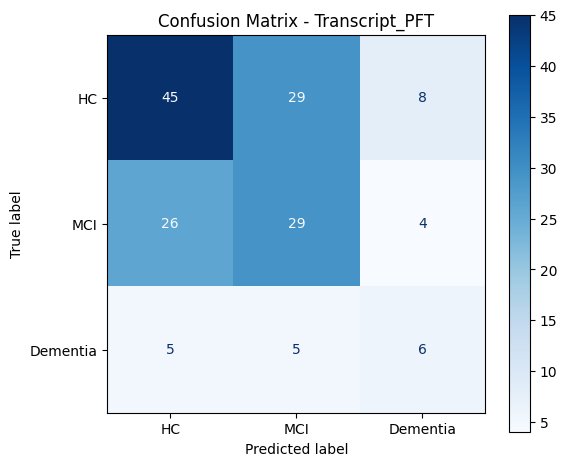


CTD (Transcript_CTD): 

Global GridSearchCV: 
Best params: {'logreg__C': 1, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 300, 'preprocess__text__min_df': 10, 'preprocess__text__ngram_range': (2, 2)}
Best CV f1_macro: 0.4824

Overall (5-fold): 
Macro F1: 0.4824 ± 0.0316

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[52 23  7]
 [20 32  6]
 [ 8  4  4]]
Total samples in CM: 156

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.65      0.63      0.64        82
           1       0.54      0.55      0.55        58
           2       0.24      0.25      0.24        16

    accuracy                           0.56       156
   macro avg       0.48      0.48      0.48       156
weighted avg       0.57      0.56      0.57       156



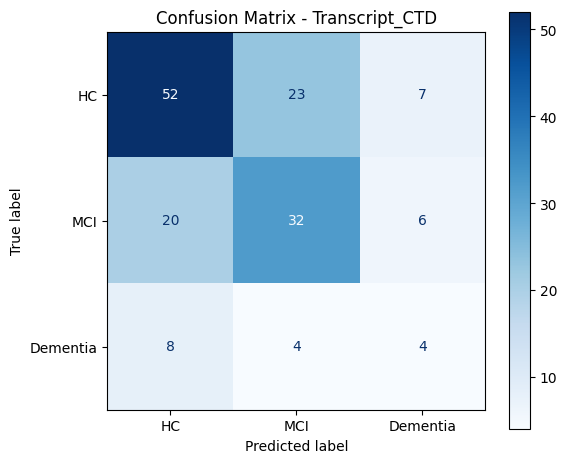


SFT (Transcript_SFT): 

Global GridSearchCV: 
Best params: {'logreg__C': 100000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 1.0, 'preprocess__text__max_features': 100, 'preprocess__text__min_df': 8, 'preprocess__text__ngram_range': (1, 1)}
Best CV f1_macro: 0.4981

Overall (5-fold): 
Macro F1: 0.4981 ± 0.0710

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[51 24  3]
 [16 32 10]
 [ 7  4  5]]
Total samples in CM: 152

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        78
           1       0.53      0.55      0.54        58
           2       0.28      0.31      0.29        16

    accuracy                           0.58       152
   macro avg       0.50      0.51      0.50       152
weighted avg       0.59      0.58      0.58       152



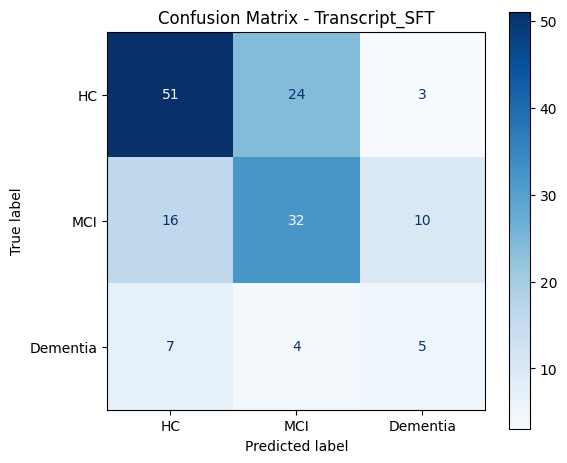


Summary of best configs: 
PFT:
  best_params: {'logreg__C': 1000, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 100, 'preprocess__text__min_df': 3, 'preprocess__text__ngram_range': (2, 2)}
  mean macro F1: 0.4576 +/- 0.0792
CTD:
  best_params: {'logreg__C': 1, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 300, 'preprocess__text__min_df': 10, 'preprocess__text__ngram_range': (2, 2)}
  mean macro F1: 0.4824 +/- 0.0316
SFT:
  best_params: {'logreg__C': 100000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 1.0, 'preprocess__text__max_features': 100, 'preprocess__text__min_df': 8, 'preprocess__text__ngram_range': (1, 1)}
  mean macro F1: 0.4981 +/- 0.0710


In [36]:
# 3 classes
results_by_transcript = {}

for df, text_col, name in [
    (pft_df, "Transcript_PFT", "PFT"),
    (ctd_df, "Transcript_CTD", "CTD"),
    (sft_df, "Transcript_SFT", "SFT"),
]:
    print(f"\n{name} ({text_col}): ") 
    final_clf, fold_scores, mean_f1, std_f1, best_params = train_eval_log_reg_text_only_kfold(
        classification="3 classes",
        df=df,
        text_col=text_col,
        label_col="Label",
        n_splits=5,
        random_state=42,
    )

    results_by_transcript[name] = {
        "final_clf": final_clf,
        "fold_scores": fold_scores,
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "best_params": best_params,
    }

print("\nSummary of best configs: ")
for name, info in results_by_transcript.items():
    print(f"{name}:")
    print("  best_params:", info["best_params"])
    print(f"  mean macro F1: {info['mean_f1']:.4f} +/- {info['std_f1']:.4f}")



PFT (Transcript_PFT): 

Global GridSearchCV: 
Best params: {'logreg__C': 10000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 1.0, 'preprocess__text__max_features': 70, 'preprocess__text__min_df': 5, 'preprocess__text__ngram_range': (1, 1)}
Best CV f1_macro: 0.6075

Overall (5-fold): 
Macro F1: 0.6075 ± 0.0691

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[52 30]
 [31 44]]
Total samples in CM: 157

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.63      0.63      0.63        82
           1       0.59      0.59      0.59        75

    accuracy                           0.61       157
   macro avg       0.61      0.61      0.61       157
weighted avg       0.61      0.61      0.61       157



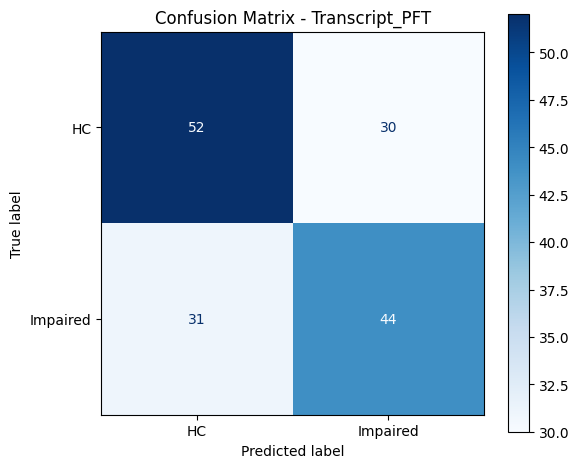


CTD (Transcript_CTD): 

Global GridSearchCV: 
Best params: {'logreg__C': 1000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 0.9, 'preprocess__text__max_features': 1000, 'preprocess__text__min_df': 1, 'preprocess__text__ngram_range': (2, 2)}
Best CV f1_macro: 0.7147

Overall (5-fold): 
Macro F1: 0.7147 ± 0.0389

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[59 23]
 [21 53]]
Total samples in CM: 156

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.74      0.72      0.73        82
           1       0.70      0.72      0.71        74

    accuracy                           0.72       156
   macro avg       0.72      0.72      0.72       156
weighted avg       0.72      0.72      0.72       156



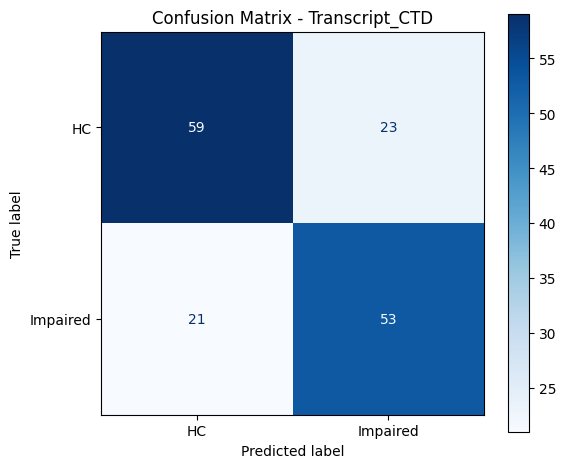


SFT (Transcript_SFT): 

Global GridSearchCV: 
Best params: {'logreg__C': 10000, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 400, 'preprocess__text__min_df': 1, 'preprocess__text__ngram_range': (1, 1)}
Best CV f1_macro: 0.7029

Overall (5-fold): 
Macro F1: 0.7029 ± 0.0338

Confusion matrix over all folds: 
rows = true labels, cols = predicted labels
[[56 22]
 [23 51]]
Total samples in CM: 152

Overall classification report (all folds combined): 
              precision    recall  f1-score   support

           0       0.71      0.72      0.71        78
           1       0.70      0.69      0.69        74

    accuracy                           0.70       152
   macro avg       0.70      0.70      0.70       152
weighted avg       0.70      0.70      0.70       152



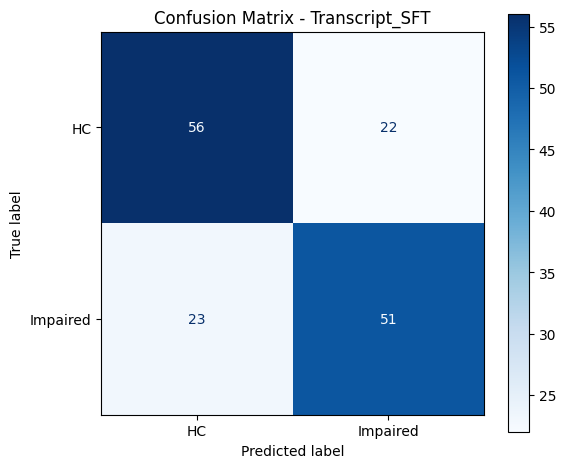


Summary of best configs for Binary Classification: 
PFT:
  best_params: {'logreg__C': 10000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 1.0, 'preprocess__text__max_features': 70, 'preprocess__text__min_df': 5, 'preprocess__text__ngram_range': (1, 1)}
  mean macro F1: 0.6075 +/- 0.0691
CTD:
  best_params: {'logreg__C': 1000, 'logreg__solver': 'newton-cg', 'preprocess__text__max_df': 0.9, 'preprocess__text__max_features': 1000, 'preprocess__text__min_df': 1, 'preprocess__text__ngram_range': (2, 2)}
  mean macro F1: 0.7147 +/- 0.0389
SFT:
  best_params: {'logreg__C': 10000, 'logreg__solver': 'lbfgs', 'preprocess__text__max_df': 0.8, 'preprocess__text__max_features': 400, 'preprocess__text__min_df': 1, 'preprocess__text__ngram_range': (1, 1)}
  mean macro F1: 0.7029 +/- 0.0338


In [37]:
# binary classification 
results_by_transcript_2 = {}

pft_df_2 = transcript_df[["Transcript_PFT", "Binary_Label"]]
ctd_df_2 = transcript_df[['Transcript_CTD', 'Binary_Label']]
sft_df_2 = transcript_df[['Transcript_SFT', 'Binary_Label']]

for df, text_col, name in [
    (pft_df_2, "Transcript_PFT", "PFT"),
    (ctd_df_2, "Transcript_CTD", "CTD"),
    (sft_df_2, "Transcript_SFT", "SFT"),
]:
    print(f"\n{name} ({text_col}): ")
    final_clf, fold_scores, mean_f1, std_f1, best_params = train_eval_log_reg_text_only_kfold(
        classification="binary",
        df=df,
        text_col=text_col,
        label_col="Binary_Label",
        n_splits=5,
        random_state=42,
    )

    results_by_transcript_2[name] = {
        "final_clf": final_clf,
        "fold_scores": fold_scores,
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "best_params": best_params,
    }

print("\nSummary of best configs for Binary Classification: ")
for name, info in results_by_transcript_2.items():
    print(f"{name}:")
    print("  best_params:", info["best_params"])
    print(f"  mean macro F1: {info['mean_f1']:.4f} +/- {info['std_f1']:.4f}")